# Task - Advanced Policy Gradient: PPO with GAE on Acrobot-v1

1. Choose one of the environments: [box2d](https://gymnasium.farama.org/environments/box2d/) or [acrobot](https://gymnasium.farama.org/environments/classic_control/acrobot/) or any 3D.
2. Implement appropriate RL method (TRPO, PPO, DDPG, TD3, etc.)
3. Show on inference that you achieve stable work.

Deadlines
- Soft 28.11.2025 23:59:59
- Hard 01.12.2025 23:59:59

**Additional requirement**: preserve classical structure of our training pipeline with two loops (episodes and steps)

# Import Libraries

In [ ]:
import math
import random
import time
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

#Hyperparameters

In [ ]:
ENV_NAME = "Acrobot-v1"
SEED = 45
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_EPISODES = 170
MAX_STEPS = 500
TRAIN_BATCH_EPISODES = 6
gamma = 0.99
LR_POLICY = 3e-4
LR_VALUE = 1e-3
POLICY_UPDATES = 6
MINI_BATCH_SIZE = 32
ENTROPY_COEF = 0.02
VALUE_COEF = 0.7
MAX_GRAD_NORM = 0.5
PRINT_INTERVAL = 10

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

#Network

In [ ]:
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        logits = self.net(x)
        return logits

class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

#GAE

In [ ]:
def compute_gae(rewards, masks, values, next_value, gamma=gamma, lam=0.95):
    values = np.append(values, next_value)
    gae = 0.0
    returns = np.zeros_like(values)
    advantages = np.zeros_like(values[:-1])
    for step in reversed(range(len(rewards))):
        delta = rewards[step] + gamma * values[step+1] * masks[step] - values[step]
        gae = delta + gamma * lam * masks[step] * gae
        advantages[step] = gae
        returns[step] = gae + values[step]
    return advantages, returns[:-1]

#PPO

In [ ]:
def ppo_update(policy_net, value_net, optim_policy, optim_value, batch, clip_eps=0.3):
    obs = batch["obs"].to(DEVICE)
    actions = batch["actions"].to(DEVICE)
    old_log_probs = batch["old_log_probs"].to(DEVICE)
    returns = batch["returns"].to(DEVICE)
    advantages = batch["advantages"].to(DEVICE)

    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    dataset_size = obs.size(0)
    idxs = np.arange(dataset_size)

    for _ in range(POLICY_UPDATES):
        np.random.shuffle(idxs)
        for start in range(0, dataset_size, MINI_BATCH_SIZE):
            mb_idx = idxs[start:start+MINI_BATCH_SIZE]
            mb_obs = obs[mb_idx]
            mb_actions = actions[mb_idx]
            mb_old_log_probs = old_log_probs[mb_idx]
            mb_returns = returns[mb_idx]
            mb_advantages = advantages[mb_idx]

            logits = policy_net(mb_obs)
            dist = Categorical(logits=logits)
            mb_new_log_probs = dist.log_prob(mb_actions)
            entropy = dist.entropy().mean()

            ratio = torch.exp(mb_new_log_probs - mb_old_log_probs)
            surr1 = ratio * mb_advantages
            surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * mb_advantages
            policy_loss = -torch.min(surr1, surr2).mean() - ENTROPY_COEF * entropy

            value_preds = value_net(mb_obs)
            value_loss = VALUE_COEF * (mb_returns - value_preds).pow(2).mean()

            optim_policy.zero_grad()
            policy_loss.backward()
            nn.utils.clip_grad_norm_(policy_net.parameters(), MAX_GRAD_NORM)
            optim_policy.step()

            optim_value.zero_grad()
            value_loss.backward()
            nn.utils.clip_grad_norm_(value_net.parameters(), MAX_GRAD_NORM)
            optim_value.step()

#Training Loop

In [ ]:
def train():
    env = gym.make(ENV_NAME)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    policy_net = PolicyNet(obs_dim, act_dim).to(DEVICE)
    value_net = ValueNet(obs_dim).to(DEVICE)
    optim_policy = optim.Adam(policy_net.parameters(), lr=LR_POLICY)
    optim_value = optim.Adam(value_net.parameters(), lr=LR_VALUE)

    batch_obs, batch_actions, batch_old_logprobs, batch_rewards, batch_masks, batch_values = [], [], [], [], [], []
    ep_count_for_batch = 0
    episode_rewards = []
    reward_deque = deque(maxlen=100)
    rolling_avg = []

    for episode in range(1, MAX_EPISODES+1):
        obs, _ = env.reset(seed=SEED + episode)
        ep_reward = 0

        for step in range(MAX_STEPS):
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            logits = policy_net(obs_tensor)
            dist = Categorical(logits=logits)
            action = dist.sample().item()
            log_prob = dist.log_prob(torch.tensor(action).to(DEVICE)).item()
            value = value_net(obs_tensor).item()

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            mask = 0.0 if done else 1.0

            batch_obs.append(obs)
            batch_actions.append(action)
            batch_old_logprobs.append(log_prob)
            batch_rewards.append(reward)
            batch_masks.append(mask)
            batch_values.append(value)

            obs = next_obs
            ep_reward += reward
            if done: break

        episode_rewards.append(ep_reward)
        reward_deque.append(ep_reward)
        rolling_avg.append(np.mean(reward_deque))
        ep_count_for_batch += 1

        if ep_count_for_batch >= TRAIN_BATCH_EPISODES:
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            next_value = value_net(obs_tensor).item()

            rewards = np.array(batch_rewards, dtype=np.float32)
            masks = np.array(batch_masks, dtype=np.float32)
            values = np.array(batch_values, dtype=np.float32)

            advantages, returns = compute_gae(rewards, masks, values, next_value)

            batch = {
                "obs": torch.tensor(np.array(batch_obs), dtype=torch.float32),
                "actions": torch.tensor(np.array(batch_actions), dtype=torch.int64),
                "old_log_probs": torch.tensor(np.array(batch_old_logprobs), dtype=torch.float32),
                "returns": torch.tensor(returns, dtype=torch.float32),
                "advantages": torch.tensor(advantages, dtype=torch.float32)
            }

            ppo_update(policy_net, value_net, optim_policy, optim_value, batch)

            batch_obs.clear()
            batch_actions.clear()
            batch_old_logprobs.clear()
            batch_rewards.clear()
            batch_masks.clear()
            batch_values.clear()
            ep_count_for_batch = 0

        if episode % PRINT_INTERVAL == 0:
            avg100 = np.mean(episode_rewards[-PRINT_INTERVAL:])
            avg_last100 = np.mean(reward_deque) if len(reward_deque)>0 else 0.0
            print(f"Ep {episode:4d} | EpReward(avg over {PRINT_INTERVAL}): {avg100:.2f} | Rolling100: {avg_last100:.2f}")

    torch.save({
        'policy_state_dict': policy_net.state_dict(),
        'value_state_dict': value_net.state_dict(),
    }, SAVE_PATH)
    print(f"Training finished. Model saved to {SAVE_PATH}")

    env.close()
    # Return plotting data
    return SAVE_PATH, episode_rewards, rolling_avg

#Inference

In [ ]:
def inference(model_path, episodes=10, render=False):
    env = gym.make(ENV_NAME, render_mode="human" if render else None)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    policy_net = PolicyNet(obs_dim, act_dim).to(DEVICE)
    value_net = ValueNet(obs_dim).to(DEVICE)

    ckpt = torch.load(model_path, map_location=DEVICE)
    policy_net.load_state_dict(ckpt['policy_state_dict'])
    value_net.load_state_dict(ckpt['value_state_dict'])
    policy_net.eval()
    value_net.eval()

    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + 100 + ep)
        ep_reward = 0
        for step in range(MAX_STEPS):
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits = policy_net(obs_tensor)
                dist = Categorical(logits=logits)
                action = dist.sample().item()
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            if terminated or truncated: break
        print(f"Inference Ep {ep+1} | Reward: {ep_reward:.2f}")
    env.close()

#Main Function

In [ ]:
if __name__ == "__main__":
    SAVE_PATH = "ppo_acrobot.pth"
    start_time = time.time()
    print("Starting training...")
    # Capture episode_rewards and rolling_avg
    model_path, episode_rewards, rolling_avg = train()
    print(f"Training time: {time.time() - start_time:.1f} seconds")

Starting training...
Ep   10 | EpReward(avg over 10): -450.50 | Rolling100: -450.50
Ep   20 | EpReward(avg over 10): -388.80 | Rolling100: -419.65
Ep   30 | EpReward(avg over 10): -234.80 | Rolling100: -358.03
Ep   40 | EpReward(avg over 10): -160.70 | Rolling100: -308.70
Ep   50 | EpReward(avg over 10): -109.00 | Rolling100: -268.76
Ep   60 | EpReward(avg over 10): -113.80 | Rolling100: -242.93
Ep   70 | EpReward(avg over 10): -89.40 | Rolling100: -221.00
Ep   80 | EpReward(avg over 10): -91.30 | Rolling100: -204.79
Ep   90 | EpReward(avg over 10): -91.40 | Rolling100: -192.19
Ep  100 | EpReward(avg over 10): -100.00 | Rolling100: -182.97
Ep  110 | EpReward(avg over 10): -84.10 | Rolling100: -146.33
Ep  120 | EpReward(avg over 10): -79.70 | Rolling100: -115.42
Ep  130 | EpReward(avg over 10): -111.60 | Rolling100: -103.10
Ep  140 | EpReward(avg over 10): -91.10 | Rolling100: -96.14
Ep  150 | EpReward(avg over 10): -77.60 | Rolling100: -93.00
Ep  160 | EpReward(avg over 10): -86.10 | R

#Evaluation

In [ ]:
print("Running evaluation (inference) for 10 episodes...")
inference(model_path, episodes=10, render=False)

Running evaluation (inference) for 10 episodes...
Inference Ep 1 | Reward: -92.00
Inference Ep 2 | Reward: -92.00
Inference Ep 3 | Reward: -80.00
Inference Ep 4 | Reward: -78.00
Inference Ep 5 | Reward: -71.00
Inference Ep 6 | Reward: -78.00
Inference Ep 7 | Reward: -96.00
Inference Ep 8 | Reward: -77.00
Inference Ep 9 | Reward: -92.00
Inference Ep 10 | Reward: -71.00


#Plot

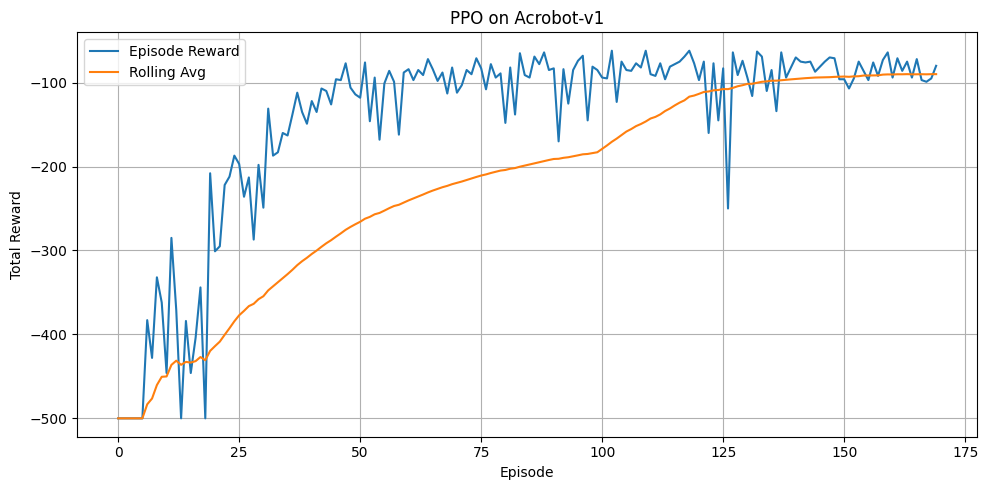

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(episode_rewards, label="Episode Reward")
plt.plot(rolling_avg, label="Rolling Avg")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO on Acrobot-v1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()